# Atmospheric Energy Budget
Below I check if I can recreate the atmospheric energy budget.

In [156]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [123]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/odp_const" for i in [5, 20]]
# exp_name = [f"thesis_season/column/depth={i}/wind_moist" for i in [5, 20]]
exp_name = 'tau_sweep/aquaplanet/depth=1/k=1'
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
vars_keep = ['temp', 'ps', 'sphum', 'vcomp', 'olr', 'swdn_toa', 'swdn_sfc', 'lwdn_sfc', 'lwup_sfc', 'flux_t', 'flux_lhe', 't_surf', 'height']
lat_min = 30
lat_max = 90
ds_base = isca_tools.load_dataset(exp_name, first_month_file=25).sel(lat=slice(lat_min, lat_max))
ds_base = ds_base[vars_keep]
ds = utils.get_annual_zonal_mean(ds_base)       # also smooths by 50 days
ds = ds.load()

In [124]:
# Get sigma levels
namelist = isca_tools.load_namelist(exp_name)
sigma_levels_half = np.asarray(namelist['vert_coordinate_nml']['bk'])
sigma_levels_full = np.convolve(sigma_levels_half, np.ones(2) / 2, 'valid')
albedo = namelist['mixed_layer_nml']['albedo_value']
ds['sigma_lev'] = ds.temp.isel(time=0, lat=0) * 0 + sigma_levels_full
ds['p_lev'] = ds.sigma_lev * ds.ps.mean()

In [229]:
get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])

# ds_base['p_lev'] = ds_base.pfull*100
ds['atmos_energy_tend_no_z'] = get_dmse_dt_xr(ds.temp, ds.sphum, 0 * ds.sphum, ds.p_lev,
                                              ds.time * utils.day_seconds,
                                              spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds['atmos_energy_tend'] = get_dmse_dt_xr(ds.temp, ds.sphum, ds.height, ds.p_lev,
                                              ds.time * utils.day_seconds,
                                              spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds['advect_tend'] = ds.atmos_energy_tend - frierson_atmospheric_heating(ds, albedo) - ds.flux_t - ds.flux_lhe
ds['temp_col'] = mass_weighted_vertical_integral(ds.temp, ds.p_lev, 'pfull', simpson_method=True)
ds['flux_rhs'] = frierson_atmospheric_heating(ds, albedo) + ds.flux_t + ds.flux_lhe

### Comparison of MSE tendency with versus without geopotential height
In single column simulations and the Donohoe 2013 paper, there is no geopotential height term. However, below it seems the geopotential height term actually has a notable effect.

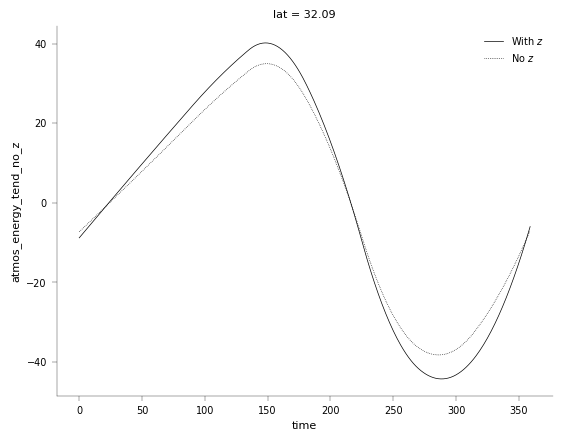

In [126]:
lat_ind = 0
ds.atmos_energy_tend.isel(lat=lat_ind).plot(color='k', label='With $z$')
ds.atmos_energy_tend_no_z.isel(lat=lat_ind).plot(color='k', linestyle=':', label='No $z$')
plt.legend()
plt.show()

### Relating meridional advection seasonality to local atmospheric temperature seasonality

The advective tendency term I just take as the residual between the RHS and LHS of the atmospheric energy budget.

Below I say that the advective term is linearly related to temperature and compute the error i.e., $\frac{1}{g}\int v\frac{dh}{dy}dp \approx \lambda_{adv}T_{col} + \text{const}$.

I use the column weighted temperature rather than lowest model level, as takes account of all levels. It appears this is a good approximation around $55\degree$ (and further south than this if only considering the first harmonic).

At higher latitudes, we see there is a phase delay between the seasonality of the column temperature and advective flux of around 10 days.

In [127]:
# Take annual harmonic of all variables for simplicity
ds_ah = ds.copy(deep=True)
for key in ds_ah:
    if 'time' in ds[key].dims:
        try:
            ds_ah[key] = get_fourier_fit_xr(ds_ah.time, ds_ah[key], n_harmonics=1, pad_coefs_phase=True)[0]
        except ValueError:
            print(key)

In [128]:
fit_linear_zero_mean_xr_1 = utils.wrap_with_apply_ufunc(
    lambda x1, y: fit_linear_zero_mean(x1, y, x2=None)[0],
    input_core_dims=[['time'], ['time']],
    output_core_dims=[[]],
)

fit_linear_zero_mean_xr_2 = utils.wrap_with_apply_ufunc(
    lambda x1, y, x2: fit_linear_zero_mean(x1, y, x2=x2),
    input_core_dims=[['time'], ['time'], ['time']],
    output_core_dims=[[], []],
)


def get_fit_coef(x1, y, x2=None):
    # Returns single fitting coefficient, i.e., c such that y=cx
    if x2 is None:
        return fit_linear_zero_mean_xr_1(x1 - x1.mean(dim='time'), y - y.mean(dim='time'))
    else:
        return fit_linear_zero_mean_xr_2(x1 - x1.mean(dim='time'), y - y.mean(dim='time'), x2 - x2.mean(dim='time'))

In [129]:
ds['advect_coef'] = get_fit_coef(ds.temp_col, ds.advect_tend)
ds_ah['advect_coef'] = get_fit_coef(ds_ah.temp_col, ds_ah.advect_tend)
ds['advect_error'] = ds.advect_tend - ds.advect_tend.mean(dim='time') - ds['advect_coef'] * (ds.temp_col - ds.temp_col.mean(dim='time'))
ds['advect_error'] = np.abs(ds.advect_error).mean(dim='time')
ds_ah['advect_error'] = ds_ah.advect_tend - ds_ah.advect_tend.mean(dim='time') - \
                        ds_ah['advect_coef'] * (ds_ah.temp_col - ds_ah.temp_col.mean(dim='time'))
ds_ah['advect_error'] = np.abs(ds_ah.advect_error).mean(dim='time')

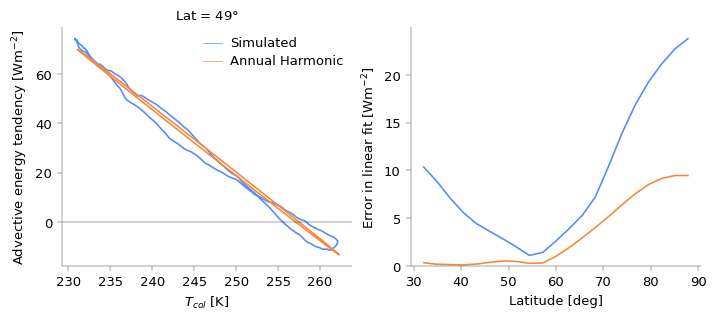

In [130]:
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col']*1.5)
lat_ind = -15
ax[0].plot(ds.temp_col.isel(lat=lat_ind), ds.advect_tend.isel(lat=lat_ind), label='Simulated')
ax[0].plot(ds_ah.temp_col.isel(lat=lat_ind), ds_ah.advect_tend.isel(lat=lat_ind), label='Annual Harmonic')
ax[1].plot(ds.lat, ds.advect_error)
ax[1].plot(ds.lat, ds_ah.advect_error)
ax[0].set_ylabel('Advective energy tendency [Wm$^{-2}$]')
ax[0].set_xlabel('$T_{col}$ [K]')
ax[0].set_title(f'Lat = {ds.lat[lat_ind]:.0f}$\degree$')
ax[1].set_xlabel(utils.label_lat)
ax[1].set_ylabel('Error in linear fit [Wm$^{-2}$]')
ax[0].legend()
ax[1].set_ylim(0, ax[1].get_ylim()[1])
update_linewidth(fig)
update_fontsize(fig)
if ds.advect_tend.isel(lat=lat_ind).min()<0:
    ax[0].axhline(0, color='k', lw=ax_linewidth)
plt.show()

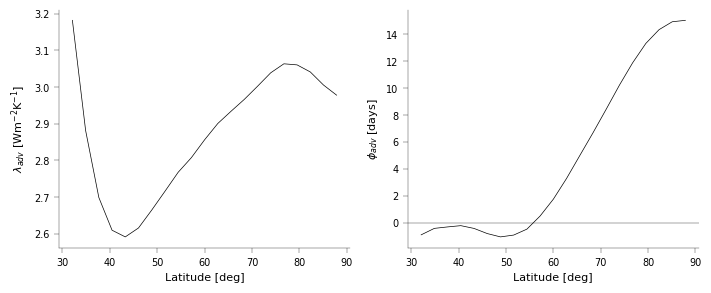

In [131]:
# Remember high temp means low advection hence use -tend in fitting so get positive amp coef
ds_ah['advect_coef_amp'], ds_ah['advect_coef_phase'] = utils.get_fit_coef_complex(-ds_ah.advect_tend, ds_ah.temp_col, ds.time)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)

fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col']*1.5)
ax[0].plot(ds_ah.lat, ds_ah['advect_coef_amp'], color='k')
ax[1].plot(ds_ah.lat, np.arctan(ds_ah['advect_coef_phase']) / omega / utils.day_seconds, color='k')
ax[0].set_ylabel('$\lambda_{adv}$ [Wm$^{-2}$K$^{-1}$]')
ax[1].set_ylabel('$\phi_{adv}$ [days]')
ax[0].set_xlabel(utils.label_lat)
ax[1].set_xlabel(utils.label_lat)
ax[1].axhline(0, color='k', lw=ax_linewidth)
plt.show()

In [132]:
def spline_deriv(x, y, s=None):
    spl = UnivariateSpline(x, y, s=s)
    return spl.derivative()(x)
spline_deriv_xr = utils.wrap_with_apply_ufunc(spline_deriv,
                                              input_core_dims=[['lat'], ['lat']],
                                              output_core_dims=[['lat']])
vm = moist_static_energy(ds.temp, ds.sphum, ds.height)*1000 * ds.vcomp
vm_integ = mass_weighted_vertical_integral(vm, ds.p_lev, 'pfull', norm=False)
cos_lat = np.asarray(np.cos(np.deg2rad(ds.lat)))
sf = np.abs(vm_integ.mean())
var = spline_deriv_xr(np.deg2rad(ds.lat), vm_integ/sf, s=None) * sf * cos_lat/ (radius_earth * cos_lat)

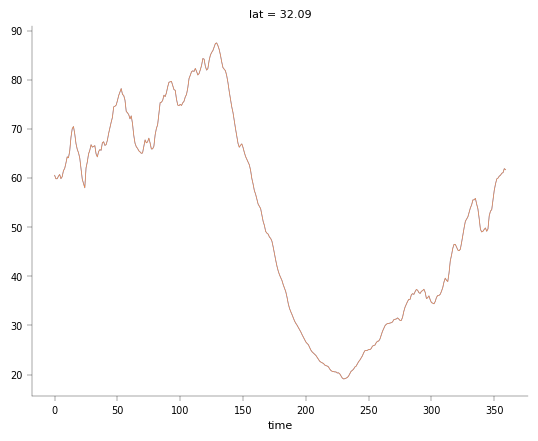

In [133]:
var.sel(lat=30, method='nearest').plot()
var.sel(lat=-20, method='nearest').plot()

In [134]:
ds.t_surf.mean(dim='time').max()-ds.t_surf.mean(dim='time').min()

<xarray.DataArray 't_surf' ()> Size: 8B
array(40.82696533)

In [162]:
def meridional_flux_divergence_numpy(
    flux: np.ndarray,
    lat_deg: np.ndarray,
    radius: float = radius_earth,
) -> np.ndarray:
    """
    Compute the spherical meridional divergence of a zonal-mean flux:

        div_y(F) = 1 / (a cos(phi)) * d[F cos(phi)] / dphi

    Parameters
    ----------
    flux : ndarray
        Zonal-mean meridional flux with latitude on the final axis,
        shape (..., nlat). For vertically integrated MSE flux this is
        typically in W m^-1.
    lat_deg : ndarray
        Latitude values in degrees, shape (nlat,), strictly increasing.
    radius : float
        Planetary radius in metres.

    Returns
    -------
    divergence : ndarray
        Meridional flux divergence, same shape as flux.
        If flux is W m^-1, output is W m^-2.
    """
    flux = np.asarray(flux)
    phi = np.deg2rad(np.asarray(lat_deg))

    if flux.shape[-1] != phi.size:
        raise ValueError("lat_deg must match the final axis of flux.")
    if np.any(np.diff(phi) <= 0):
        raise ValueError("lat_deg must be strictly increasing.")

    cosphi = np.cos(phi)

    # Differentiate F cos(phi) with respect to latitude in radians.
    d_fluxcos_dphi = np.gradient(
        flux * cosphi,
        phi,
        axis=-1,
        edge_order=2,
    )

    return d_fluxcos_dphi / (radius * cosphi)

def meridional_flux_divergence(
    flux: xr.DataArray,
    lat = None,
    lat_dim: str = "lat",
    radius: float = radius_earth,
) -> xr.DataArray:
    """
    Compute spherical meridional divergence of a zonal-mean flux.

    Calculates:
        1/(a cos(phi)) d[F cos(phi)]/dphi

    Parameters
    ----------
    flux : xr.DataArray
        A zonal-mean meridional flux, with dimension `lat_dim`.
        For example, vertically integrated MSE flux <[v m]>, in W m^-1.
    lat : xr.DataArray, optional
        Latitude coordinate in degrees. Defaults to flux[lat_dim].
    lat_dim : str
        Latitude dimension name.
    radius : float
        Planetary radius in metres.

    Returns
    -------
    xr.DataArray
        Meridional divergence. For input W m^-1, output is W m^-2.
    """
    if lat is None:
        lat = flux[lat_dim]

    result = xr.apply_ufunc(
        meridional_flux_divergence_numpy,
        flux,
        lat,
        input_core_dims=[[lat_dim], [lat_dim]],
        output_core_dims=[[lat_dim]],
        kwargs={"radius": radius},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float64],
        dask_gufunc_kwargs={
            "output_sizes": {lat_dim: flux.sizes[lat_dim]},
        },
    )

    result.name = "meridional_flux_divergence"
    result.attrs = {
        "long_name": "spherical meridional divergence of zonal-mean flux",
        "formula": "1/(a cos(phi)) d(F cos(phi))/dphi",
        "units": "W m^-2",
    }

    return result

In [248]:
ds_use = ds.copy(deep=True)
var = get_dmse_dt_xr(ds_use.temp, ds_use.sphum, ds_use.height, ds_use.pfull*100,
                     ds_use.time * utils.day_seconds,
                     spline_smoothing_factor=1e-5)[1]

In [249]:
vm = ds_use.vcomp * moist_static_energy(ds_use.temp, ds_use.sphum, ds_use.height)*1000
vm_col = mass_weighted_vertical_integral(
    vm,
    pressure=ds_use.sigma_lev * ds_use.ps.mean(),
    lev_dim="pfull",
    norm=False,
)
mse_conv = -meridional_flux_divergence(
    vm_col,
    lat=vm["lat"],
    lat_dim="lat",
)
flux_rhs = frierson_atmospheric_heating(ds, albedo) + ds.flux_t + ds.flux_lhe
mse_tend = ds.atmos_energy_tend

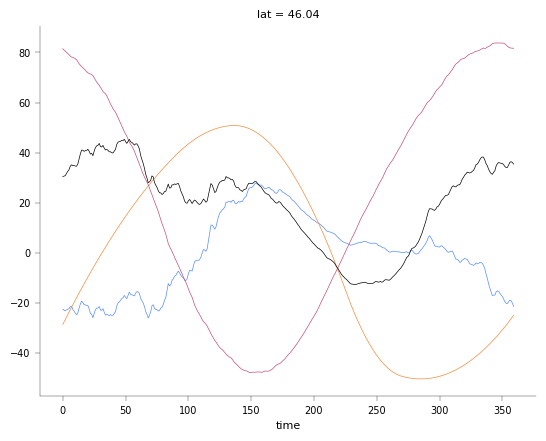

In [259]:
lat_ind = 5
(-mse_conv).isel(lat=lat_ind).plot()
ds['atmos_energy_tend'].isel(lat=lat_ind).plot()
flux_rhs = frierson_atmospheric_heating(ds, albedo) + ds.flux_t + ds.flux_lhe
(-flux_rhs).isel(lat=lat_ind).plot()
(ds['atmos_energy_tend']-flux_rhs-mse_conv).isel(lat=lat_ind).plot(color='k')

In [232]:
lat_ind = 5
ds_use = ds_base.isel(lat=lat_ind).load()
dmse_dt_use = get_dmse_dt_xr(ds_use.temp, ds_use.sphum, ds_use.height, ds_use.pfull*100,
                                              ds_use.time * utils.day_seconds,
                                              spline_smoothing_factor=0)[1]
flux_rhs = frierson_atmospheric_heating(ds_use, albedo) + ds_use.flux_t + ds_use.flux_lhe

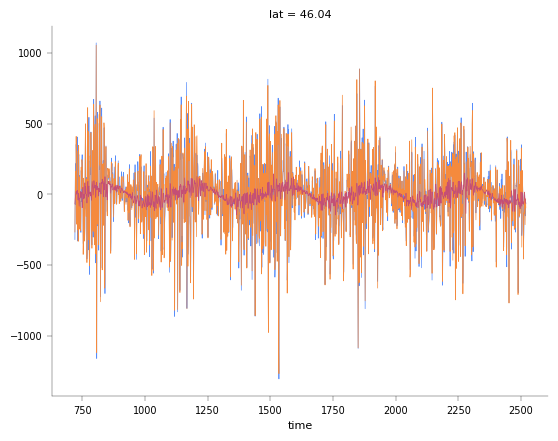

In [233]:
dmse_dt_use.isel(lon=3).plot()
dmse_dt_use.isel(lon=2).plot()
dmse_dt_use.mean(dim='lon').plot()
# plt.ylim(-100, 100)

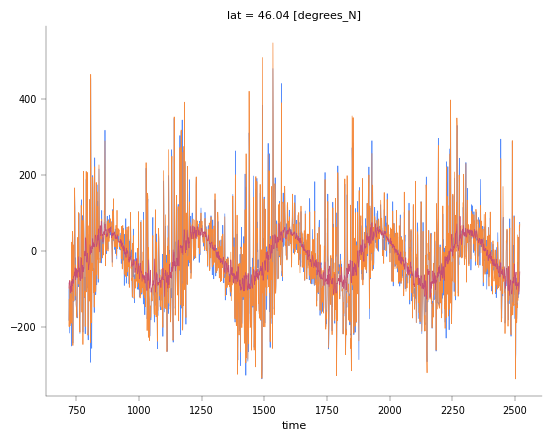

In [234]:
flux_rhs.isel(lon=3).plot()
flux_rhs.isel(lon=2).plot()
flux_rhs.mean(dim='lon').plot()

In [262]:
ds_use = ds_base.load()

In [283]:
mse = moist_static_energy(ds_use.temp, ds_use.sphum, ds_use.height) * 1000
vm = ds_use.vcomp * mse
vm_col = mass_weighted_vertical_integral(
    vm,
    pressure=ds_use.pfull*100,
    lev_dim="pfull",
    norm=False,
)
mse_conv = -meridional_flux_divergence(
    vm_col,
    lat=vm["lat"],
    lat_dim="lat",
)

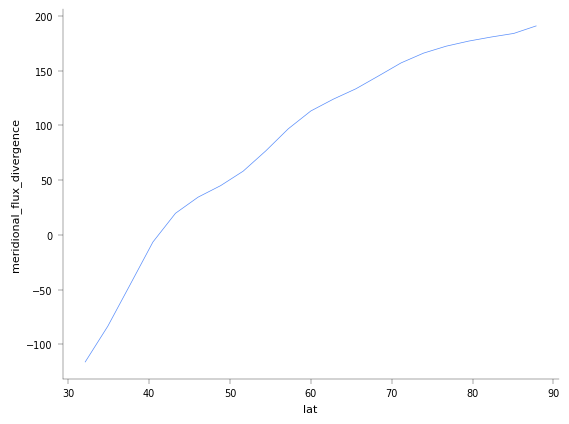

In [316]:
mse_conv.mean(dim=['time', 'lon']).plot()

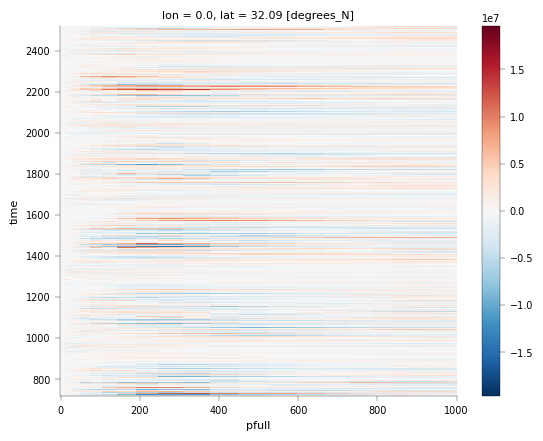

In [314]:
vm.isel(lat=0, lon=0).plot()

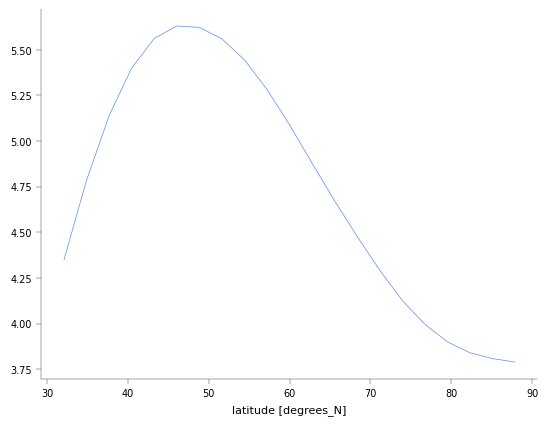

In [302]:
np.abs(var).mean(dim=['lon', 'time']).plot()

In [285]:
dp = np.abs(ds_use.pfull.diff('pfull'))*100
weights = dp / g
var_int = (vm * weights).sum('pfull')

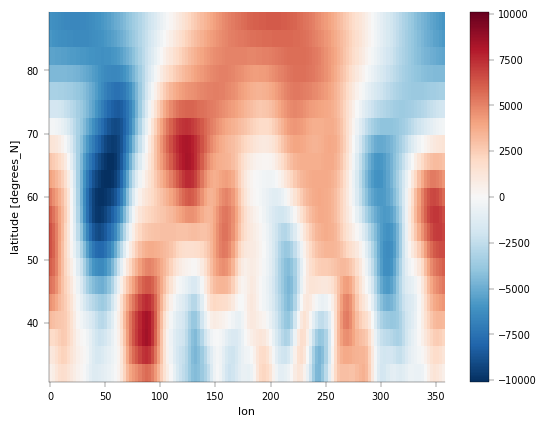

In [287]:
v_mass_flux = mass_weighted_vertical_integral(
    ds_use.vcomp,
    pressure=ds_use.pfull*100,
    lev_dim="pfull",
    norm=False,
)

v_mass_flux_time_mean = v_mass_flux.mean("time")

v_mass_flux_time_mean.plot()

In [284]:
vm_col.max()

<xarray.DataArray ()> Size: 8B
array(1.37725295e+11)

In [275]:
print("MSE [J kg^-1]:", mse.mean().item())
print("v*MSE [W m kg^-1]:", np.abs(vm).mean().item())
print("Column MSE flux [W m^-1]:", np.abs(vm_col).mean().item())
print("MSE convergence [W m^-2]:", np.abs(mse_conv).mean().item())
print("Max abs convergence [W m^-2]:", np.abs(mse_conv).max().item())

MSE [J kg^-1]: 341445.1875
v*MSE [W m kg^-1]: 1401471.75
Column MSE flux [W m^-1]: 1427098.3143205964
MSE convergence [W m^-2]: 1.55315777954555
Max abs convergence [W m^-2]: 29.461302713312595


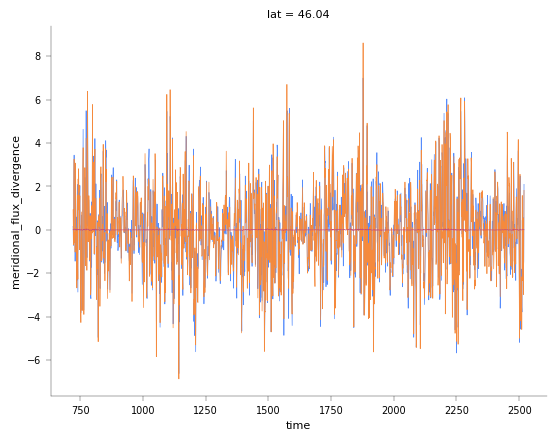

In [276]:
mse_conv.isel(lat=lat_ind, lon=3).plot()
mse_conv.isel(lat=lat_ind, lon=2).plot()
mse_conv.isel(lat=lat_ind).mean(dim='lon').plot()

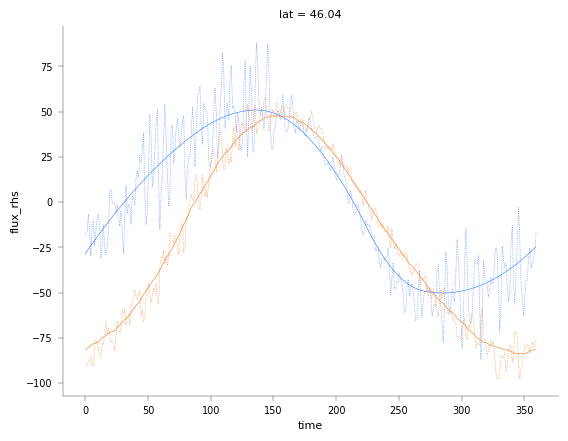

In [235]:
annual_mean(dmse_dt_use.mean(dim='lon')).plot(color='C0', linestyle=':')
annual_mean(flux_rhs.mean(dim='lon')).plot(color='C1', linestyle=':')
ds['atmos_energy_tend'].isel(lat=lat_ind).plot(color='C0')
ds['flux_rhs'].isel(lat=lat_ind).plot(color='C1')